### `LLM based review handling conditional Workflow`

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv

a:\Learning_LangGraph\lg_venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv()
model = ChatGroq(model="openai/gpt-oss-120b")

In [3]:
class SentimentSchema(BaseModel):

    sentiment: Literal['positive', 'negative', 'neutral'] = Field(description="The sentiment of the review")

In [4]:
class DiagnosisSchema(BaseModel):

    issue_type: Literal['UX', 'Performance', 'Bug', 'Support', 'Other'] = Field(description= 'The category of issue mentioned in the review')
    tone: Literal['Angry', 'Frustrated', 'Disapointed', 'Satisfied', 'Usetisfied', 'Calm'] = Field(description= 'The emotional tone expressed by the user in the review')
    urgency: Literal['Low', 'Medium', 'High'] = Field(description= 'How urgent or critical the issue appears to be')

In [5]:
structured_model = model.with_structured_output(schema=SentimentSchema)
structured_model2 = model.with_structured_output(schema=DiagnosisSchema)

In [6]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative', 'neutral']
    diagnosis: dict
    response: str

In [22]:
def extract_sentiment(state : ReviewState):
    prompt = f'Extract the sentiment of the following review: {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}


def check_sentiment(state: ReviewState) -> Literal['run_diagnosis', 'positive_response_generator']:
    if state['sentiment'] == 'negative':
        return 'run_diagnosis'
    else:
        return 'positive_response_generator'


def positive_response_generator(state : ReviewState):

    prompt = f"""Generate a warm thak you message in response to this review: \n\n{state['review']}
    Also, kindly ask the user to leave a feedback on our website."""

    output = model.invoke(prompt).content
    return {'response' : output}


def run_diagnosis(state : ReviewState):

    prompt = f"""diagnose this negative review: \n\n{state['review']}\n
    Return issue_type, tone, and urgency"""

    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}


def negative_response_generator(state: ReviewState):

    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant .
    The user had a {diagnosis['issue_type']} issue, sounded {diagnosis['tone']}, and marked urgency as {diagnosis['urgency']}.
    Generate an empathetic, helpful resolution message in response."""

    output = model.invoke(prompt).content

    return {'response': output}


In [23]:
graph = StateGraph(ReviewState)

graph.add_node('extract_sentiment', extract_sentiment)
graph.add_node('positive_response_generator', positive_response_generator)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response_generator', negative_response_generator)

graph.add_edge(START, 'extract_sentiment')

graph.add_conditional_edges('extract_sentiment', check_sentiment)

graph.add_edge('positive_response_generator', END)

graph.add_edge('run_diagnosis', 'negative_response_generator')
graph.add_edge('negative_response_generator', END)

In [24]:
workflow = graph.compile()

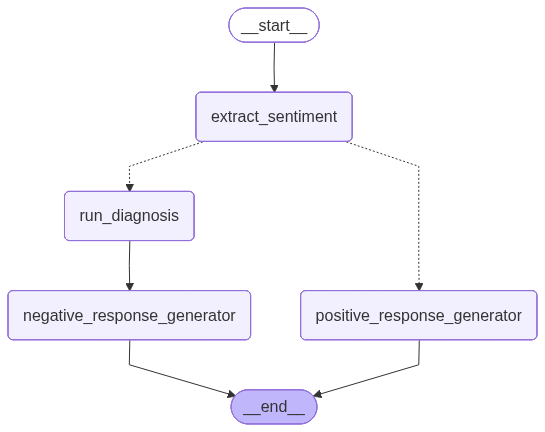

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [26]:
workflow.invoke({'review': "I am very disappointed with the product. It stopped working after a week and customer support has been unhelpful."})

{'review': 'I am very disappointed with the product. It stopped working after a week and customer support has been unhelpful.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'Disapointed', 'urgency': 'High'},
 'response': 'Hi\u202f[Customer Name],\n\nI’m really sorry to hear that you’re experiencing this bug – I completely understand how frustrating that can be, especially when you need things to work smoothly.\u202fYour urgency flag lets us know this is a high‑priority issue, and I’m treating it as such.\n\n**Here’s what we’ll do right away:**\n\n1. **Gather the details we need to pinpoint the problem**  \n   Could you please share the following information (if you haven’t already)?  \n   - The exact error message or screenshots of the failure.  \n   - Steps you took leading up to the bug (a brief “reproduce” flow helps a lot).  \n   - The environment you’re running in (e.g., OS, browser version, app version, API endpoint, etc.).  \n   - Any recent changes or d

In [27]:
workflow.invoke({'review': "This software is incredibly intuitive, featuring a sleek interface that makes managing complex tasks feel effortless. The performance is consistently lightning-fast, and the automated tools have significantly boosted my daily productivity."})

{'review': 'This software is incredibly intuitive, featuring a sleek interface that makes managing complex tasks feel effortless. The performance is consistently lightning-fast, and the automated tools have significantly boosted my daily productivity.',
 'sentiment': 'positive',
 'response': 'Thank you so much for sharing your experience! 🌟  \nWe’re thrilled to hear that you find the interface intuitive, the performance lightning‑fast, and the automated tools a real boost to your productivity. Knowing that our software makes managing complex tasks feel effortless truly validates all the hard work our team puts in.\n\nIf you have a moment, we’d love for you to share this feedback on our website as well—it helps others discover the same smooth experience you’re enjoying. \n\nThanks again for your kind words and continued support! 🚀'}